# Tea Leaf Disease Classification — ResNet50 Transfer Learning
CSC4093/DSC4213 Programming Assignment 02

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
import os, time, copy
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ── Configuration ─────────────────────────────────────────
DATA_DIR    = './dataset'   # <-- Update to your dataset path
NUM_CLASSES = 3
BATCH_SIZE  = 16
NUM_EPOCHS  = 15
LR          = 0.001
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')


Using device: cpu


In [3]:
# ── Data Transforms ───────────────────────────────────────
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ── Dataset Split: 70% train / 15% val / 15% test ─────────
full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transforms)
class_names  = full_dataset.classes
print(f'Classes: {class_names}  |  Total images: {len(full_dataset)}')

n_total = len(full_dataset)
n_train = int(0.70 * n_total)
n_val   = int(0.15 * n_total)
n_test  = n_total - n_train - n_val

train_set, val_set, test_set = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)
val_set.dataset         = copy.deepcopy(full_dataset)
val_set.dataset.transform  = val_transforms
test_set.dataset        = copy.deepcopy(full_dataset)
test_set.dataset.transform = val_transforms

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f'Train: {n_train} | Val: {n_val} | Test: {n_test}')


Classes: ['algal leaf', 'brown blight', 'white spot']  |  Total images: 368
Train: 257 | Val: 55 | Test: 56


In [4]:
# ── ResNet50 Model (Transfer Learning) ────────────────────
model_resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Freeze all layers except layer4 and fc
for name, param in model_resnet.named_parameters():
    if 'layer4' not in name and 'fc' not in name:
        param.requires_grad = False

# Replace FC layer with Dropout + 3-class output
in_features = model_resnet.fc.in_features
model_resnet.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, NUM_CLASSES)
)
model_resnet = model_resnet.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model_resnet.parameters()), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

trainable = sum(p.numel() for p in model_resnet.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable:,}')


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /Users/udamshakya/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100.0%


Trainable parameters: 14,970,883


In [5]:
# ── Training Loop ─────────────────────────────────────────
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs):
    history  = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    best_acc = 0.0
    best_wts = copy.deepcopy(model.state_dict())
    t0 = time.time()
    for epoch in range(num_epochs):
        for phase, loader in [('train', train_loader), ('val', val_loader)]:
            model.train() if phase == 'train' else model.eval()
            running_loss, running_corrects = 0.0, 0
            for inputs, labels in loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss    = criterion(outputs, labels)
                    preds   = outputs.argmax(dim=1)
                    if phase == 'train': loss.backward(); optimizer.step()
                running_loss     += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()
            epoch_loss = running_loss / len(loader.dataset)
            epoch_acc  = running_corrects / len(loader.dataset)
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc)
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_wts = copy.deepcopy(model.state_dict())
        scheduler.step()
        print(f'Epoch [{epoch+1:02d}/{num_epochs}]  '
              f'Train Loss: {history["train_loss"][-1]:.4f}  Acc: {history["train_acc"][-1]:.4f}  |  '
              f'Val Loss: {history["val_loss"][-1]:.4f}  Acc: {history["val_acc"][-1]:.4f}')
    elapsed = time.time() - t0
    print(f'Done in {elapsed//60:.0f}m {elapsed%60:.0f}s | Best Val Acc: {best_acc:.4f}')
    model.load_state_dict(best_wts)
    return model, history

model_resnet, history_resnet = train_model(
    model_resnet, train_loader, val_loader, criterion, optimizer, scheduler, NUM_EPOCHS
)
torch.save(model_resnet.state_dict(), 'resnet50_tea_disease.pth')


Epoch [01/15]  Train Loss: 0.9586  Acc: 0.5992  |  Val Loss: 2.4701  Acc: 0.7818
Epoch [02/15]  Train Loss: 0.5761  Acc: 0.7899  |  Val Loss: 0.4756  Acc: 0.8182
Epoch [03/15]  Train Loss: 0.3371  Acc: 0.8716  |  Val Loss: 0.3850  Acc: 0.8545
Epoch [04/15]  Train Loss: 0.2124  Acc: 0.9261  |  Val Loss: 0.7552  Acc: 0.7273
Epoch [05/15]  Train Loss: 0.3417  Acc: 0.8638  |  Val Loss: 0.5275  Acc: 0.8182
Epoch [06/15]  Train Loss: 0.2524  Acc: 0.9105  |  Val Loss: 0.4285  Acc: 0.8000
Epoch [07/15]  Train Loss: 0.1425  Acc: 0.9533  |  Val Loss: 0.3085  Acc: 0.8727
Epoch [08/15]  Train Loss: 0.1719  Acc: 0.9300  |  Val Loss: 0.2851  Acc: 0.8727
Epoch [09/15]  Train Loss: 0.1758  Acc: 0.9339  |  Val Loss: 0.5413  Acc: 0.8182
Epoch [10/15]  Train Loss: 0.1696  Acc: 0.9494  |  Val Loss: 0.3370  Acc: 0.8545
Epoch [11/15]  Train Loss: 0.1094  Acc: 0.9728  |  Val Loss: 0.3689  Acc: 0.8727
Epoch [12/15]  Train Loss: 0.0655  Acc: 0.9844  |  Val Loss: 0.2890  Acc: 0.8364
Epoch [13/15]  Train Loss: 0

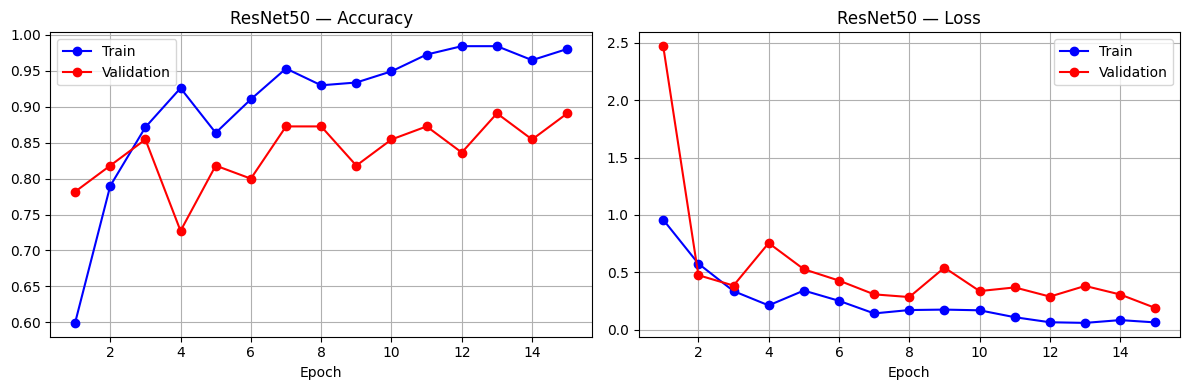

In [6]:
# ── Training Curves ───────────────────────────────────────
epochs_range = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_range, history_resnet['train_acc'], 'b-o', label='Train')
axes[0].plot(epochs_range, history_resnet['val_acc'],   'r-o', label='Validation')
axes[0].set_title('ResNet50 — Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(epochs_range, history_resnet['train_loss'], 'b-o', label='Train')
axes[1].plot(epochs_range, history_resnet['val_loss'],   'r-o', label='Validation')
axes[1].set_title('ResNet50 — Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig('resnet50_training_curves.png', dpi=150)
plt.show()


              precision    recall  f1-score   support

  algal leaf       0.93      0.93      0.93        15
brown blight       0.94      0.94      0.94        16
  white spot       0.96      0.96      0.96        25

    accuracy                           0.95        56
   macro avg       0.94      0.94      0.94        56
weighted avg       0.95      0.95      0.95        56



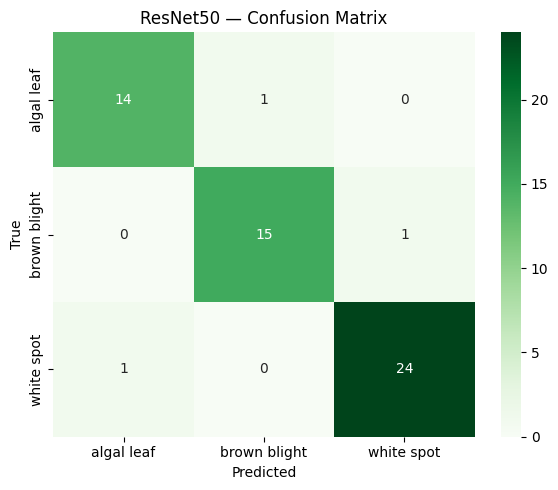

In [7]:
# ── Test Set Evaluation ───────────────────────────────────
def evaluate_model(model, test_loader, class_names, title, cmap, fname):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs.to(DEVICE))
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())
    print(classification_report(all_labels, all_preds, target_names=class_names))
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=class_names, yticklabels=class_names)
    plt.title(title); plt.ylabel('True'); plt.xlabel('Predicted')
    plt.tight_layout(); plt.savefig(fname, dpi=150); plt.show()

evaluate_model(model_resnet, test_loader, class_names,
               'ResNet50 — Confusion Matrix', 'Greens', 'resnet50_confusion_matrix.png')
